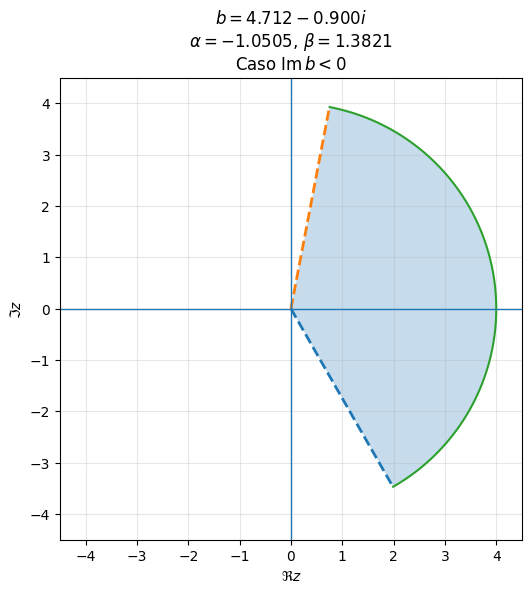

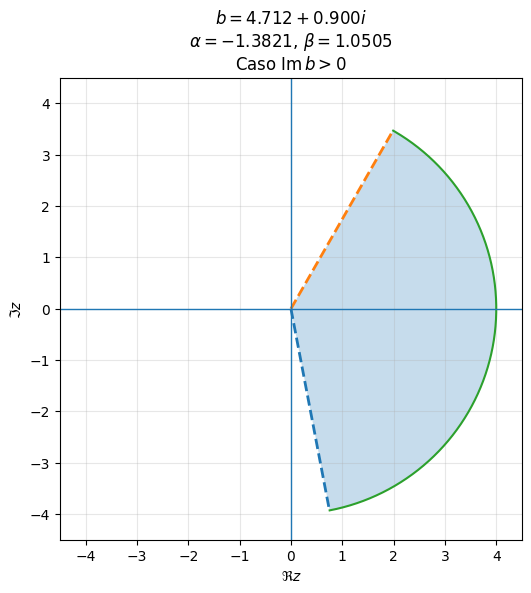

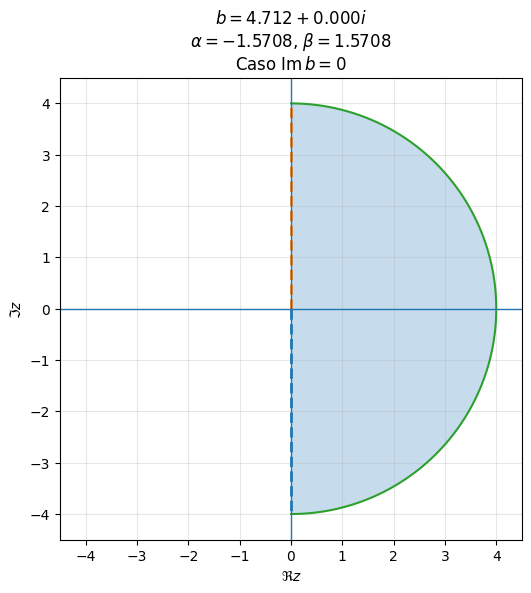

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def angulos_Kb(b):
    """
    Regresa los ángulos (alpha, beta) que definen el sector abierto K_b
    según la definición del paper.

    b: número complejo con Re(b) en (0, 2*pi)
    """
    re_b = np.real(b)
    im_b = np.imag(b)

    if not (0 < re_b < 2 * np.pi):
        raise ValueError("Se requiere 0 < Re(b) < 2*pi.")

    # Caso Im(b) = 0
    if np.isclose(im_b, 0.0):
        alpha = -np.pi / 2
        beta = np.pi / 2
        return alpha, beta

    # Caso Im(b) < 0
    if im_b < 0:
        alpha = np.arctan((2 * np.pi - re_b) / im_b)
        beta = np.arctan((-re_b) / im_b)
        return alpha, beta

    # Caso Im(b) > 0
    alpha = np.arctan((-re_b) / im_b)
    beta = np.arctan((2 * np.pi - re_b) / im_b)
    return alpha, beta


def dibujar_Kb(b, R=4, n_theta=500, titulo_extra=""):
    """
    Dibuja el conjunto K_b = {z = r e^{i theta} : r > 0, alpha < theta < beta}
    para el número complejo b.

    Parámetros:
    - b: número complejo
    - R: radio visual máximo del dibujo
    - n_theta: cantidad de puntos para dibujar el arco
    - titulo_extra: texto adicional para el título
    """
    alpha, beta = angulos_Kb(b)

    # Como K_b es abierto, no incluimos exactamente los bordes
    eps = 1e-3
    theta = np.linspace(alpha + eps, beta - eps, n_theta)

    x = R * np.cos(theta)
    y = R * np.sin(theta)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Región del sector
    ax.fill(
        np.concatenate(([0], x, [0])),
        np.concatenate(([0], y, [0])),
        alpha=0.25,
        label=r"$K_b$"
    )

    # Rayos frontera (líneas punteadas porque el sector es abierto)
    ax.plot([0, R * np.cos(alpha)], [0, R * np.sin(alpha)], "--", linewidth=2)
    ax.plot([0, R * np.cos(beta)], [0, R * np.sin(beta)], "--", linewidth=2)

    # Arco exterior solo para visualizar la abertura
    ax.plot(x, y, linewidth=1.5)

    # Ejes
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$\Re z$")
    ax.set_ylabel(r"$\Im z$")

    re_b = np.real(b)
    im_b = np.imag(b)
    titulo = (
        rf"$b = {re_b:.3f} {'+' if im_b >= 0 else '-'} {abs(im_b):.3f}i$"
        "\n"
        rf"$\alpha = {alpha:.4f}$, $\beta = {beta:.4f}$"
    )
    if titulo_extra:
        titulo += "\n" + titulo_extra

    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)

    # Límites de la gráfica
    ax.set_xlim(-R - 0.5, R + 0.5)
    ax.set_ylim(-R - 0.5, R + 0.5)

    plt.show()


# =========================
# EJEMPLOS PARA CADA CASO
# =========================

# Caso 1: Im(b) < 0
b1 = 1.5*np.pi  - 0.9j
dibujar_Kb(b1, titulo_extra=r"Caso $\operatorname{Im} b < 0$")

# Caso 2: Im(b) > 0
b2 = 1.5*np.pi  + 0.9j
dibujar_Kb(b2, titulo_extra=r"Caso $\operatorname{Im} b > 0$")

# Caso 3: Im(b) = 0
b3 = 1.5*np.pi  + 0j
dibujar_Kb(b3, titulo_extra=r"Caso $\operatorname{Im} b = 0$")

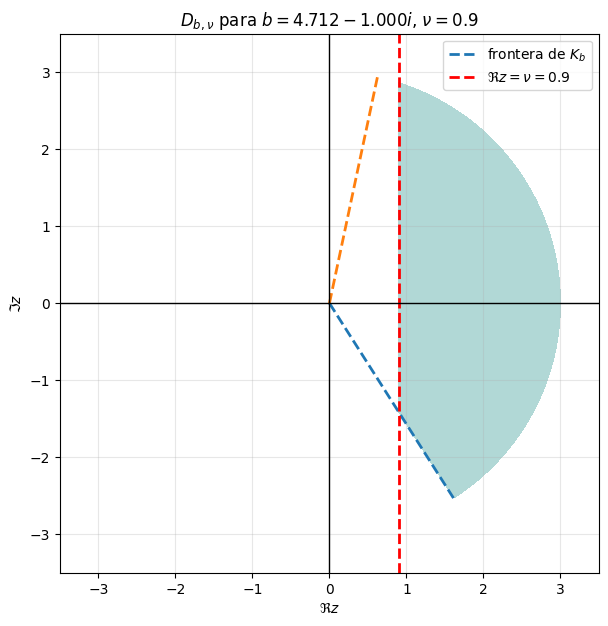

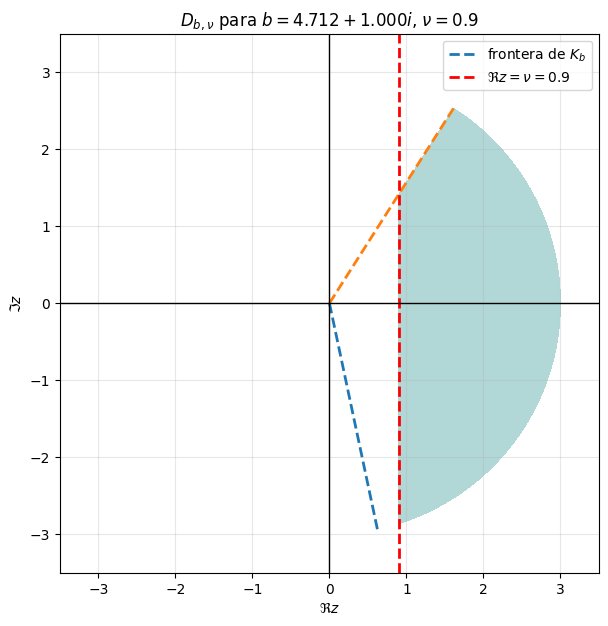

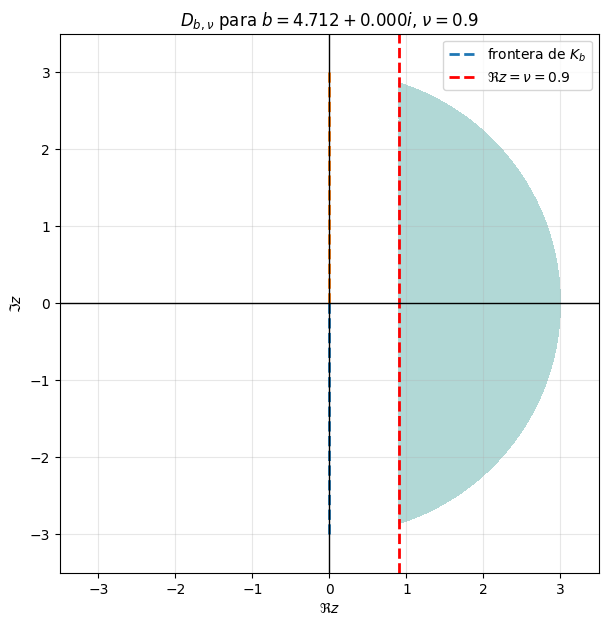

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def angulos_Kb(b):
    """
    Regresa (alpha, beta) tales que
    K_b = { z = r e^{i theta} : r > 0, alpha < theta < beta }.
    """
    re_b = np.real(b)
    im_b = np.imag(b)

    if not (0 < re_b < 2 * np.pi):
        raise ValueError("Se requiere 0 < Re(b) < 2*pi.")

    if np.isclose(im_b, 0.0):
        return -np.pi / 2, np.pi / 2

    if im_b < 0:
        alpha = np.arctan((2 * np.pi - re_b) / im_b)
        beta  = np.arctan((-re_b) / im_b)
        return alpha, beta

    alpha = np.arctan((-re_b) / im_b)
    beta  = np.arctan((2 * np.pi - re_b) / im_b)
    return alpha, beta


def dibujar_D_b_nu(b, nu, R=3, n_r=400, n_theta=500):
    """
    Dibuja la región D_{b,nu} = { z in K_b : Re z > nu }.

    Parámetros:
    - b: número complejo con 0 < Re(b) < 2*pi
    - nu: número real en (0,1)
    - R: radio máximo visual
    """
    if not (0 < nu < 1):
        raise ValueError("Se requiere 0 < nu < 1.")

    alpha, beta = angulos_Kb(b)

    # Mallado polar
    r = np.linspace(0.001, R, n_r)
    theta = np.linspace(alpha + 1e-3, beta - 1e-3, n_theta)
    RR, TT = np.meshgrid(r, theta)

    X = RR * np.cos(TT)
    Y = RR * np.sin(TT)

    # Condición Re(z) > nu
    mask = X > nu

    fig, ax = plt.subplots(figsize=(7, 7))

    # Región D_{b,nu}
    ax.contourf(X, Y, mask.astype(float), levels=[0.5, 1.5], alpha=0.35)

    # Fronteras del sector K_b (punteadas porque K_b es abierto)
    ax.plot([0, R*np.cos(alpha)], [0, R*np.sin(alpha)], '--', linewidth=2, label=r'frontera de $K_b$')
    ax.plot([0, R*np.cos(beta)],  [0, R*np.sin(beta)],  '--', linewidth=2)

    # Recta Re(z) = nu
    ax.axvline(nu, color='red', linestyle='--', linewidth=2, label=rf'$\Re z = \nu = {nu}$')

    # Ejes
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-R - 0.5, R + 0.5)
    ax.set_ylim(-R - 0.5, R + 0.5)
    ax.grid(True, alpha=0.3)

    re_b = np.real(b)
    im_b = np.imag(b)
    ax.set_title(
        rf"$D_{{b,\nu}}$ para $b={re_b:.3f}{'+' if im_b >= 0 else '-'}{abs(im_b):.3f}i$, "
        rf"$\nu={nu}$"
    )
    ax.set_xlabel(r'$\Re z$')
    ax.set_ylabel(r'$\Im z$')
    ax.legend()

    plt.show()


# =========================
# EJEMPLOS
# =========================

# Caso Im(b) < 0
b1 = 1.5*np.pi - 1j

nu1 = 0.9
dibujar_D_b_nu(b1, nu1)

# Caso Im(b) > 0
b2 = 1.5*np.pi + 1j

nu2 = 0.9
dibujar_D_b_nu(b2, nu2)

# Caso Im(b) = 0
b3 = 1.5*np.pi + 0j

nu3 = 0.9
dibujar_D_b_nu(b3, nu3)